In [1]:
import ROOT
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT.EnableImplicitMT(10)

Welcome to JupyROOT 6.28/04


In [2]:
pathmc = '/rxc_lustre/ivan.cambon/TrackCalibmu_AA_tuples/MC/OO_2025/trackeffmu_OO_mc_2025.root'


tdf_mc = ROOT.RDataFrame("charmonium_mu_mu_VM_mup_Tag/DecayTree", pathmc)
sinal = tdf_mc.Filter("mup_MC_MOTHER_ID == 443 & mum_MC_MOTHER_ID == 443")

In [2]:
pathdata = "/rxc_lustre/ivan.cambon/TrackCalibmu_AA_tuples/data/OO_2025/00319259_*_1.trackeff_muons_oo.root"
tdf = ROOT.RDataFrame("charmonium_mu_mu_VM_mup_Tag/DecayTree", pathdata)
background = tdf.Filter("dimuon_M < 2850 | dimuon_M > 3350")

-------------------------
Set LHCb Style - May 2021
-------------------------


Info in <TCanvas::Print>: png file dimuon_mass_Down_sinal_vs_bkg.png has been created


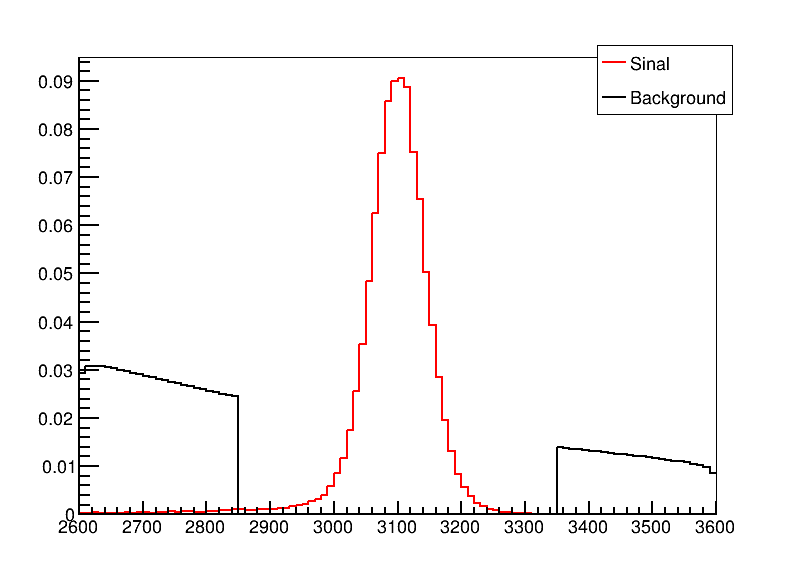

In [4]:
# Crear histogramas (RResultPtr)
h_sinal = sinal.Histo1D(("h_sinal","Dimuon mass sinal",100,2600,3600), "dimuon_M")
h_background  = background.Histo1D(("h_background","Dimuon mass background",100,2600,3600), "dimuon_M")

# Converter a TH1 reais
hist_sinal = h_sinal.GetValue()
hist_bkg  = h_background.GetValue()

# Debuxar
c = ROOT.TCanvas("c", "Dimuon mass", 800, 600)

hist_sinal.SetLineColor(ROOT.kRed)
hist_sinal.SetLineWidth(2)

hist_bkg.SetLineColor(ROOT.kBlack)
hist_bkg.SetLineWidth(2)

# Debuxamos normalizado
hist_sinal.DrawNormalized("HIST")
hist_bkg.DrawNormalized("HIST SAME")

# Lenda
leg = ROOT.TLegend(0.75, 0.8, 0.92, 0.92)
leg.AddEntry(hist_sinal, "Sinal", "l")
leg.AddEntry(hist_bkg, "Background", "l")
leg.Draw()

# Estilo LHCb
ROOT.gROOT.ProcessLine(".L lhcbStyle.C")
ROOT.lhcbStyle()

c.Draw()
c.SaveAs("dimuon_mass_Down_sinal_vs_bkg.png")

In [ ]:
import os
outdir = "plots_variables"
os.makedirs(outdir, exist_ok=True)

ROOT.gROOT.ProcessLine(".L lhcbStyle.C")
ROOT.lhcbStyle()


variables = [
    'mup_CHI2DOF', 'mup_P', 'mup_BPVIPCHI2',
    'mum_CHI2DOF', 'mum_P', 'mum_PT',
    'mum_BPVIP', 'mum_BPVIPCHI2', 'mum_GHOSTPROB',
    'dimuon_DOCA_12', 'dimuon_BPVIP',
    'dimuon_CHI2DOF', 'dimuon_PT', 'mum_PID_MU', 'dimuon_M'
]


var_cfg = {

    # ===== Mu+ (tag ou probe segundo o caso) =====
    "mup_CHI2DOF": {
        "bins": 100,
        "xmin": 0,
        "xmax": 4,
        "xlabel": r"$\chi^2/\mathrm{ndof}(\mu^+)$"
    },

    "mup_P": {
        "bins": 100,
        "xmin": 0,
        "xmax": 120000,   # MeV
        "xlabel": r"$p(\mu^+)$ [MeV/c]"
    },

    "mup_BPVIPCHI2": {
        "bins": 100,
        "xmin": 0,
        "xmax": 30,
        "xlabel": r"$\chi^2_{\mathrm{IP}}(\mu^+)$"
    },

    # ===== Mu− =====
    "mum_CHI2DOF": {
        "bins": 100,
        "xmin": 0,
        "xmax": 3,
        "xlabel": r"$\chi^2/\mathrm{ndof}(\mu^-)$"
    },

    "mum_P": {
        "bins": 100,
        "xmin": 0,
        "xmax": 100000,
        "xlabel": r"$p(\mu^-)$ [MeV/c]"
    },

    "mum_PT": {
        "bins": 100,
        "xmin": 0,
        "xmax": 10000,
        "xlabel": r"$p_T(\mu^-)$ [MeV/c]"
    },

    "mum_BPVIP": {
        "bins": 100,
        "xmin": 0,
        "xmax": 1.0,      # mm
        "xlabel": r"$\mathrm{IP}(\mu^-)$ [mm]"
    },

    "mum_BPVIPCHI2": {
        "bins": 100,
        "xmin": 0,
        "xmax": 100,
        "xlabel": r"$\chi^2_{\mathrm{IP}}(\mu^-)$"
    },

    "mum_GHOSTPROB": {
        "bins": 100,
        "xmin": 0,
        "xmax": 0.3,
        "xlabel": r"$\mathrm{GhostProb}(\mu^-)$"
    },

    "mum_PID_MU": {
        "bins": 100,
        "xmin": -10,
        "xmax": 10,
        "xlabel": r"$\mathrm{PID}_\mu(\mu^-)$"
    },

    # ===== Dimuon =====
    "dimuon_DOCA_12": {
        "bins": 100,
        "xmin": 0,
        "xmax": 1.5,      # mm
        "xlabel": r"$\mathrm{DOCA}(\mu^+\mu^-)$ [mm]"
    },

    "dimuon_BPVIP": {
        "bins": 100,
        "xmin": 0,
        "xmax": 1.5,
        "xlabel": r"$\mathrm{IP}(\mu^+\mu^-)$ [mm]"
    },

    "dimuon_CHI2DOF": {
        "bins": 100,
        "xmin": 0,
        "xmax": 3,
        "xlabel": r"$\chi^2/\mathrm{ndof}(\mu^+\mu^-)$"
    },

    "dimuon_PT": {
        "bins": 100,
        "xmin": 0,
        "xmax": 10000,
        "xlabel": r"$p_T(\mu^+\mu^-)$ [MeV/c]"
    },

    "dimuon_M": {
        "bins": 120,
        "xmin": 2600,
        "xmax": 3600,
        "xlabel": r"$m(\mu^+\mu^-)$ [MeV/c^2]"
    },
}



for var in variables:

    cfg = var_cfg[var]

    bins = cfg["bins"]
    xmin = cfg["xmin"]
    xmax = cfg["xmax"]
    xlabel = cfg["xlabel"]

    # histogramas RDataFrame
    h_mc  = tdf_mc.Histo1D((f"h_mc_{var}", "", bins, xmin, xmax), var)
    h_bkg = background.Histo1D((f"h_bkg_{var}", "", bins, xmin, xmax), var)    # converter a TH1 reais
    hist_mc  = h_mc.GetValue()
    hist_bkg = h_bkg.GetValue()

    # estilo
    hist_mc.SetLineColor(ROOT.kBlue)
    hist_mc.SetLineWidth(2)

    hist_bkg.SetLineColor(ROOT.kRed)
    hist_bkg.SetLineWidth(2)

    hist_mc.GetXaxis().SetTitle(xlabel)
    hist_mc.GetYaxis().SetTitle("Normalized events")

    # canvas
    c = ROOT.TCanvas(f"c_{var}", var, 800, 600)

    hist_mc.DrawNormalized("HIST")
    hist_bkg.DrawNormalized("HIST SAME")

    # lenda
    leg = ROOT.TLegend(0.70,0.75,0.90,0.90)
    leg.AddEntry(hist_mc, "MC", "l")
    leg.AddEntry(hist_bkg, "Background", "l")
    leg.Draw()

    c.SaveAs(f"{outdir}/{var}_VM.png")

In [3]:
dataMupDowntag_bkg = tdf.Filter("dimuon_BPVIP < 0.35 && dimuon_DOCA_12 < 0.55 &&  dimuon_PT > 2100 &&mum_BPVIP < 0.035 && mum_CHI2DOF < 1.5 && mum_P > 10000 && mum_PID_MU > 0 && mum_PT > 1800 && mup_CHI2DOF < 1.3 && mum_P > 10000 && mum_PT > 800")

-------------------------
Set LHCb Style - May 2021
-------------------------


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file dimuon_mass_VM_corte_vs_uncut.png has been created


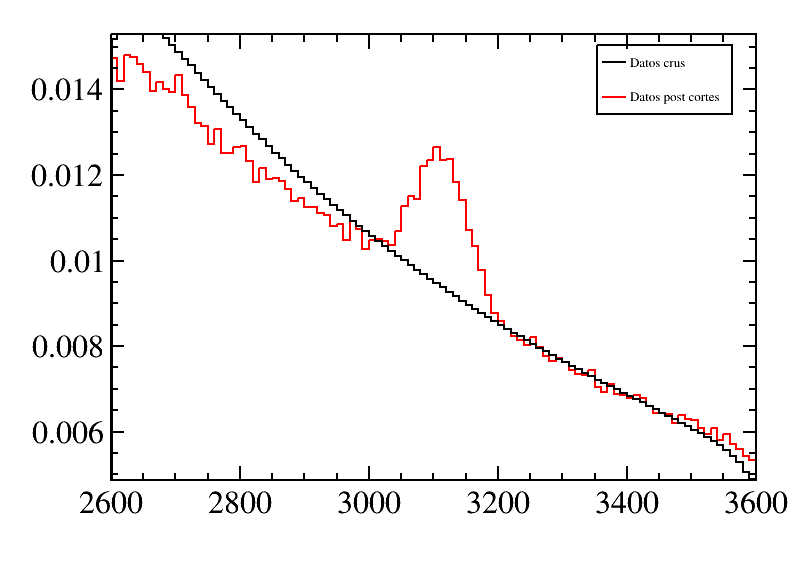

In [8]:
# Crear histogramas (RResultPtr)
h_mass_before = tdf.Histo1D(("h_mass_before","Dimuon mass before cuts",100,2600,3600), "dimuon_M")
h_mass_after  = dataMupDowntag_bkg.Histo1D(("h_mass_after","Dimuon mass after cuts",100,2600,3600), "dimuon_M")

# Converter a TH1 reais
hist_before = h_mass_before.GetValue()
hist_after  = h_mass_after.GetValue()

# Debuxar
c = ROOT.TCanvas("c", "Dimuon mass", 800, 600)

hist_before.SetLineColor(ROOT.kBlack)
hist_before.SetLineWidth(2)

hist_after.SetLineColor(ROOT.kRed)
hist_after.SetLineWidth(2)

# Debuxamos normalizado
hist_after.DrawNormalized("HIST")
hist_before.DrawNormalized("HIST SAME")

# Lenda
leg = ROOT.TLegend(0.75, 0.8, 0.92, 0.92)
leg.AddEntry(hist_before, "Datos crus", "l")
leg.AddEntry(hist_after, "Datos post cortes", "l")
leg.Draw()

# Estilo LHCb
ROOT.gROOT.ProcessLine(".L lhcbStyle.C")
ROOT.lhcbStyle()

c.Draw()
c.SaveAs("dimuon_mass_VM_corte_vs_uncut.png")

In [4]:
match = dataMupDowntag_bkg.Filter("nMatch > 0")
fail = dataMupDowntag_bkg.Filter("nMatch == 0")




-------------------------
Set LHCb Style - May 2021
-------------------------


Info in <TCanvas::Print>: png file OO_match_vs_fail_VM.png has been created


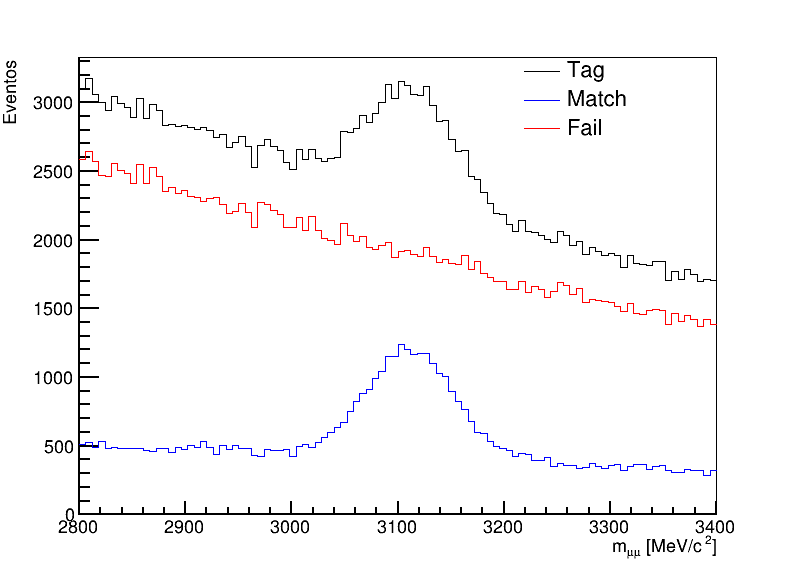

In [ ]:
c = ROOT.TCanvas("c", "", 800, 600)
h_tag   = dataMupDowntag_bkg.Histo1D(("tag","",100,2800,3400),"dimuon_M")
h_match = match.Histo1D(("match","",100,2800,3400),"dimuon_M")
h_fail  = fail.Histo1D(("fail","",100,2800,3400),"dimuon_M")

hist_tag   = h_tag.GetValue()
hist_match = h_match.GetValue()
hist_fail  = h_fail.GetValue() 

hist_tag.SetLineColor(ROOT.kBlack)
hist_match.SetLineColor(ROOT.kBlue)
hist_fail.SetLineColor(ROOT.kRed)

hist_tag.GetXaxis().SetTitle("m_{#mu#mu} [MeV/c^{2}]")
hist_tag.GetYaxis().SetTitle("Eventos")
hist_tag.SetMinimum(0)

hist_tag.Draw("HIST")
hist_match.Draw("HIST SAME")
hist_fail.Draw("HIST SAME")

leg = ROOT.TLegend(0.65, 0.75, 0.9, 0.9)
leg.SetBorderSize(0)
leg.SetFillStyle(0)
leg.AddEntry(hist_tag,   "Tag",   "l")
leg.AddEntry(hist_match, "Match", "l")
leg.AddEntry(hist_fail,  "Fail",  "l")
leg.Draw()

ROOT.gROOT.ProcessLine(".L lhcbStyle.C")
ROOT.lhcbStyle()

c.Draw()
c.SaveAs("OO_match_vs_fail_VM.png")

In [5]:
mass = ROOT.RooRealVar("dimuon_M", "m(#mu#mu) [MeV/c^{2}]", 2800, 3400) 

data_match = match.AsNumpy(["dimuon_M"])
roo_data_match = ROOT.RooDataSet.from_numpy(
    {"dimuon_M": data_match["dimuon_M"]},
    [mass]
)

data_fail = fail.AsNumpy(["dimuon_M"])
roo_data_fail = ROOT.RooDataSet.from_numpy(
    {"dimuon_M": data_fail["dimuon_M"]},
    [mass])


data_tag = dataMupDowntag_bkg.AsNumpy(["dimuon_M"])
roo_data_tag = ROOT.RooDataSet.from_numpy(
    {"dimuon_M": data_tag["dimuon_M"]},
    [mass]
)

[#0] WARNING:DataHandling -- RooDataSet.from_numpy() Ignored 27606 out-of-range events
[#0] WARNING:DataHandling -- RooDataSet.from_numpy() Ignored 137875 out-of-range events
[#0] WARNING:DataHandling -- RooDataSet.from_numpy() Ignored 165481 out-of-range events


In [ ]:
# SAMPLE MATCH
alpha = ROOT.RooRealVar("alpha", "alpha", 2.107)
alpha.setConstant(True) # ¡Moi importante! Isto evita que MINUIT os toque
n = ROOT.RooRealVar("n", "n", 1.5)
n.setConstant(True)

# 3. Parámetros LIBRES (inicializados cos valores do MC pero con marxe)
mean   = ROOT.RooRealVar("mean", "mean", 3102.25, 3070, 3130)
# Damos un pouco máis de límite superior aos sigmas porque os datos reais teñen peor resolución
sigma1 = ROOT.RooRealVar("sigma1", "sigma gauss", 15, 5, 25)  
sigma2 = ROOT.RooRealVar("sigma2", "sigma cb", 42.8838, 15, 60)
sig_frac = ROOT.RooRealVar("sig_frac", "fraction Gauss/CB", 0.03757, 0, 1)

# 4. Construción do sinal
gauss = ROOT.RooGaussian("gauss", "Gaussian", mass, mean, sigma1)
cb    = ROOT.RooCBShape("cb", "Crystal Ball", mass, mean, sigma2, alpha, n)
signal = ROOT.RooAddPdf("signal", "Gauss + CB", [gauss, cb], [sig_frac])

# 5. Parámetros LIBRES do Fondo
tau = ROOT.RooRealVar("tau", "tau bkg", -0.001297, -0.02, 0.0)
bkg = ROOT.RooExponential("bkg", "Exponential Bkg", mass, tau)

# 6. Yields (Número de eventos). Subimos moito os límites iniciais porque tes máis datos
nsig = ROOT.RooRealVar("nsig", "N signal", 28000, 0, 200000)
nbkg = ROOT.RooRealVar("nbkg", "N background", 20000, 0, 200000)

# 7. Modelo Total e Axuste
model_total = ROOT.RooAddPdf("model_total", "Signal + Background", [signal, bkg], [nsig, nbkg])


model_total.fitTo(roo_data_match)

<cppyy.gbl.RooFitResult object at 0x(nil)>

[#1] INFO:Minimization -- p.d.f. provides expected number of events, including extended term in likelihood.
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization --  The following expressions will be evaluated in cache-and-track mode: (gauss,cb,bkg)
 **********
 **    1 **SET PRINT           1
 **********
 **********
 **    2 **SET NOGRAD
 **********
 PARAMETER DEFINITIONS:
    NO.   NAME         VALUE      STEP SIZE      LIMITS
     1 mean         3.10225e+03  6.00000e+00    3.07000e+03  3.13000e+03
     2 nbkg         2.00000e+04  1.00000e+04    0.00000e+00  2.00000e+05
     3 nsig         2.80000e+04  1.40000e+04    0.00000e+00  2.00000e+05
     4 sig_frac     3.75700e-02  1.87850e-02    0.00000e+00  1.00000e+00
     5 sigma1       1.50000e+01  2.00000e+00    5.00000e+00  2.50000e+01
     6 sigma2       4.28838e+01  4.50000e+00    1.50000e+01  6.00000e+01
     7 tau         -1.29700e-03  6.48500e-04   -2.00000e-02  0.000

In [7]:
# SAMPLE TAG
alpha_tag = ROOT.RooRealVar("alpha", "alpha", 2.107)
alpha_tag.setConstant(True) # ¡Moi importante! Isto evita que MINUIT os toque
n_tag = ROOT.RooRealVar("n", "n", 1.5)
n_tag.setConstant(True)

# 3. Parámetros LIBRES (inicializados cos valores do MC pero con marxe)
mean_tag   = ROOT.RooRealVar("mean", "mean", 3102.25, 3070, 3130)
# Damos un pouco máis de límite superior aos sigmas porque os datos reais teñen peor resolución
sigma1_tag = ROOT.RooRealVar("sigma1", "sigma gauss", 15, 5, 25)  
sigma2_tag = ROOT.RooRealVar("sigma2", "sigma cb", 42.8838, 15, 60)
sig_frac_tag = ROOT.RooRealVar("sig_frac", "fraction Gauss/CB", 0.03757, 0, 1)

# Construción do sinal do Tag
gauss_tag = ROOT.RooGaussian("gauss_tag", "Gaussian", mass, mean_tag, sigma1_tag)
cb_tag    = ROOT.RooCBShape("cb_tag", "Crystal Ball", mass, mean_tag, sigma2_tag, alpha_tag, n_tag)
signal_tag = ROOT.RooAddPdf("signal_tag", "Gauss + CB", [gauss_tag, cb_tag], [sig_frac_tag])

# 3. Parámetros LIBRES do Fondo do Tag
tau_tag = ROOT.RooRealVar("tau_tag", "tau bkg", -0.0106, -1.0, 0.0)
bkg_tag = ROOT.RooExponential("bkg_tag", "Exponential Bkg", mass, tau_tag)

# 4. Yields (Número de eventos). Lixeiramente superiores porque Tag = Match + Fail
nsig_tag = ROOT.RooRealVar("nsig_tag", "N signal tag", 30000, 0, 300000)
nbkg_tag = ROOT.RooRealVar("nbkg_tag", "N background tag", 25000, 0, 300000)

# 5. Modelo Total e Axuste á mostra TAG
model_tag = ROOT.RooAddPdf("model_tag", "Signal + Background Tag", [signal_tag, bkg_tag], [nsig_tag, nbkg_tag])

# Lanzamos o fit contra os datos que me dixeches
model_tag.fitTo(roo_data_tag)

<cppyy.gbl.RooFitResult object at 0x(nil)>

[#1] INFO:Minimization -- p.d.f. provides expected number of events, including extended term in likelihood.
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization --  The following expressions will be evaluated in cache-and-track mode: (gauss_tag,cb_tag,bkg_tag)
 **********
 **   10 **SET PRINT           1
 **********
 **********
 **   11 **SET NOGRAD
 **********
 PARAMETER DEFINITIONS:
    NO.   NAME         VALUE      STEP SIZE      LIMITS
     1 mean         3.10225e+03  6.00000e+00    3.07000e+03  3.13000e+03
     2 nbkg_tag     2.50000e+04  1.25000e+04    0.00000e+00  3.00000e+05
     3 nsig_tag     3.00000e+04  1.50000e+04    0.00000e+00  3.00000e+05
     4 sig_frac     3.75700e-02  1.87850e-02    0.00000e+00  1.00000e+00
     5 sigma1       1.50000e+01  2.00000e+00    5.00000e+00  2.50000e+01
     6 sigma2       4.28838e+01  4.50000e+00    1.50000e+01  6.00000e+01
     7 tau_tag     -1.06000e-02  5.30000e-03   -1.0000

In [8]:
# SAMPLE FAIL
#mass = ROOT.RooRealVar("mass", "m_{#mu#mu} [MeV/c^{2}]", 2800, 3400)

# 1. A Exponencial protexida
# Obrigamos a tau a ser negativo (caída) e poñemos límites súper estritos
# para evitar desbordamentos numéricos.
tau_fail = ROOT.RooRealVar("tau_fail", "tau fail", -0.001, -0.2, 0.0)
bkg_fail = ROOT.RooExponential("bkg_fail", "Exponential Bkg Fail", mass, tau_fail)

# 2. Número de eventos
# Como a liña rolda os 700 eventos por bin de media, en total terás decenas de miles.
# Subimos o límite superior para que MINUIT teña espazo.
nbkg_fail = ROOT.RooRealVar("nbkg_fail", "N background fail", 50000, 0, 500000)

# 3. Construímos o modelo e fiteamos
# (Usamos RooExtendPdf cando é unha soa función con yield)
model_fail = ROOT.RooExtendPdf("model_fail", "Background Only Fail", bkg_fail, nbkg_fail)

model_fail.fitTo(roo_data_fail)

<cppyy.gbl.RooFitResult object at 0x(nil)>

[#1] INFO:Minimization -- p.d.f. provides expected number of events, including extended term in likelihood.
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
 **********
 **    1 **SET PRINT           1
 **********
 **********
 **    2 **SET NOGRAD
 **********
 PARAMETER DEFINITIONS:
    NO.   NAME         VALUE      STEP SIZE      LIMITS
     1 nbkg_fail    5.00000e+04  2.50000e+04    0.00000e+00  5.00000e+05
     2 tau_fail    -1.00000e-03  5.00000e-04   -2.00000e-01  0.00000e+00
 **********
 **    3 **SET ERR         0.5
 **********
 **********
 **    4 **SET PRINT           1
 **********
 **********
 **    5 **SET STR           1
 **********
 NOW USING STRATEGY  1: TRY TO BALANCE SPEED AGAINST RELIABILITY
 **********
 **    6 **MIGRAD        1000           1
 **********
 FIRST CALL TO USER FUNCTION AT NEW START POINT, WITH IFLAG=4.
 START MIGRAD MINIMIZATION.  STRATEGY  1.  CONVERGENCE WHEN EDM .LT. 1.00e-03
 FCN=-812123 FROM MIGRAD    ST

[#1] INFO:Plotting -- RooPlot::updateFitRangeNorm: New event count of 55373 will supercede previous event count of 249574 for normalization of PDF projections
[#1] INFO:Plotting -- RooPlot::updateFitRangeNorm: New event count of 194201 will supercede previous event count of 55373 for normalization of PDF projections
-------------------------
Set LHCb Style - May 2021
-------------------------


Info in <TCanvas::Print>: png file Axustes_VM_OO.png has been created


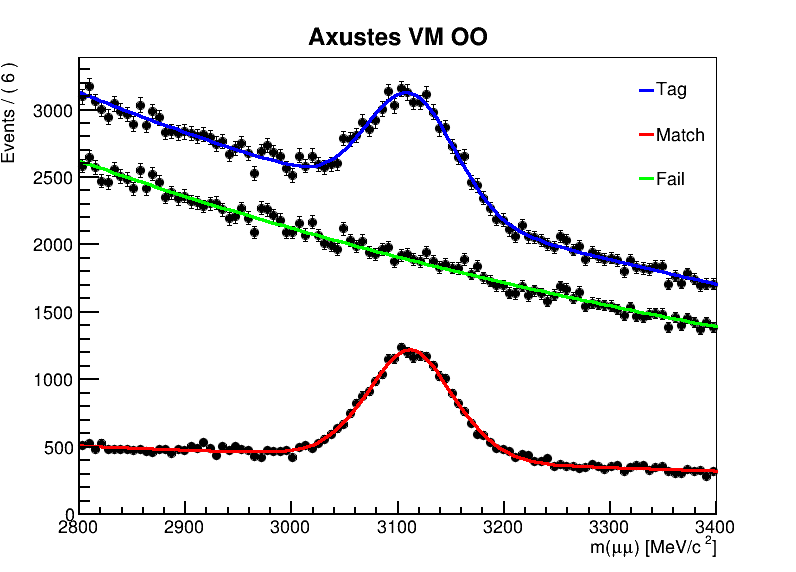

In [ ]:
# Creamos o frame
frame_all = mass.frame(ROOT.RooFit.Title("Comparacion Tag vs Match vs Fail"))

# 1. TAG 
roo_data_tag.plotOn(frame_all, ROOT.RooFit.Name("DataTag")) 
model_tag.plotOn(frame_all, ROOT.RooFit.Name("ModelTag"))

# 2. MATCH 
roo_data_match.plotOn(frame_all, 
                      ROOT.RooFit.Name("DataMatch"), 
                      ROOT.RooFit.MarkerColor(ROOT.kBlack), 
                      ROOT.RooFit.LineColor(ROOT.kBlack)) 

model_total.plotOn(frame_all, 
                   ROOT.RooFit.Name("ModelMatch"), 
                   ROOT.RooFit.LineColor(ROOT.kRed)) 

# 3. FAIL 
roo_data_fail.plotOn(frame_all, 
                      ROOT.RooFit.Name("DataFail"), 
                      ROOT.RooFit.MarkerColor(ROOT.kBlack), 
                      ROOT.RooFit.LineColor(ROOT.kBlack))

model_fail.plotOn(frame_all, 
                   ROOT.RooFit.Name("ModelFail"), 
                   ROOT.RooFit.LineColor(ROOT.kGreen))

# Debuxamos
c_final = ROOT.TCanvas("c_final", "Canvas Final", 800, 600)
leg = ROOT.TLegend(0.80, 0.65, 0.90, 0.88)
leg.SetBorderSize(0)      # Quítalle o bordo negro á lenda
leg.SetFillStyle(0)       # Fai que o fondo da lenda sexa transparente
leg.SetTextSize(0.035)    # Tamaño da letra

# Engadimos os modelos usando os nomes exactos. 
# O "L" significa que queremos que na lenda se debuxe unha Liña.
leg.AddEntry(frame_all.findObject("ModelTag"), "Tag", "L")
leg.AddEntry(frame_all.findObject("ModelMatch"), "Match", "L")
leg.AddEntry(frame_all.findObject("ModelFail"), "Fail", "L")


ROOT.gROOT.ProcessLine(".L lhcbStyle.C")
ROOT.lhcbStyle()
frame_all.Draw()
leg.Draw("SAME")
c_final.Draw()
title_text = ROOT.TLatex()
title_text.SetNDC()              
title_text.SetTextSize(0.045)    
title_text.SetTextFont(62)       # Tipo de letra 
title_text.SetTextAlign(21)      # Aliñación: 2 (centro horizontal), 1 (abaixo vertical)

# Debuxamos o título na posición X=0.5 (centro) e Y=0.92 (arriba do todo)
title_text.DrawLatex(0.5, 0.92, "Axustes VM OO")
c_final.SaveAs("Axustes_VM_OO.png")